## LangChain vs LangGraph

### LangChain

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
from langchain_google_genai import ChatGoogleGenerativeAI

llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash")

In [3]:
query = '너는 누구니?'

llm.invoke(query)

AIMessage(content='저는 구글에서 훈련한 대규모 언어 모델입니다.\n\n다양한 질문에 답변하고, 정보를 제공하며, 창의적인 콘텐츠를 생성하는 데 도움을 드릴 수 있습니다. 저는 감정이나 의식을 가지고 있지 않으며, 독립적인 존재가 아닌 프로그램입니다.\n\n궁금한 점이 있다면 언제든지 물어봐 주세요!', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--1920b78c-41c9-4f82-ae18-3496202bae8e-0', usage_metadata={'input_tokens': 6, 'output_tokens': 837, 'total_tokens': 843, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 763}})

### LangGraph

LangGraph는 LangChain을 기반으로 한 **순환 그래프** 프레임워크.
상태(State)를 중심으로 노드(Node)와 엣지(Edge)를 연결하여 복잡한 에이전트 워크플로우를 구현하는 데 특화됐음.

#### State(상태)
* **공유 객체:** 그래프의 모든 노드에서 접근하고 수정할 수 있는 **공통 데이터 객체**임.
* **`TypedDict` 기반:** 주로 `typing_extensions.TypedDict`를 사용해 정의됨. 이는 에이전트의 현재 상황(메시지, 도구 호출 결과 등)을 저장하는 역할을 함.
* **상태 관리:** 노드가 실행되면 상태가 업데이트되고, 업데이트된 상태는 다음 노드로 전달됨.

#### Node(노드)
* **작업 단위:** 그래프의 기본 **실행(작업) 단위**. 함수나 `Runnable` 객체로 정의됨.
* **입력/출력:** 상태를 입력으로 받고, 상태를 업데이트하여 반환함.
* **유형:**
    * **LLM 노드:** LLM을 호출해 응답을 생성함.
    * **도구 노드:** 외부 도구(API, 검색 엔진 등)를 실행함.
    * **함수 노드:** 특정 로직을 수행하는 파이썬 함수임.

#### Edge(엣지)
* **흐름 제어:** 노드 간의 연결을 나타내며, 워크플로우의 **실행 순서**를 결정함.
* **유형:**
    * **일반 엣지:** 특정 노드에서 다음 노드로 무조건 이동함.
    * **조건부 엣지:** 노드의 출력에 따라 다음 노드를 동적으로 결정함.
* **순환 구조:** 엣지를 통해 특정 노드로 다시 돌아가는 순환 고리(loop)를 만들 수 있음.

In [ ]:
from typing import Annotated
from typing_extensions import TypedDict

from langgraph.graph.message import add_messages  # 매 단계마다 새로운 메시지를 추가함
from langchain_core.messages import AnyMessage # HumanMessage, AIMessage, SystemMessage, ToolMessage, FunctionMessage를 나타내는 추상화된 타입

# 상태 객체 생성용 클래스
# 딕셔너리 구조
class AgentState(TypedDict):
    messages: list[Annotated[AnyMessage, add_messages]] # add_messages 리듀서 함수는 상태 키의 값(메시지)을 업데이트(덮어쓰는 대신 리스트에 추가)

In [5]:
from langgraph.graph import StateGraph # 상태 기반의 그래프를 생성하는 클래스(에이전트의 상태 관리, Node와 Edge 연결)

# 그래프 객체
graph_builder = StateGraph(AgentState)

In [ ]:
# 함수 노드
def generate(state: AgentState) -> AgentState:
    """
    `generate` 노드는 사용자의 질문을 받아서 응답을 생성하는 노드입니다.
    """
    messages = state['messages']
    ai_message = llm.invoke(messages)

    return {'messages': [ai_message]}

In [7]:
# 그래스 객체에 노드 추가
graph_builder.add_node('generate', generate)

In [8]:
from langgraph.graph import START, END # 그래프의 시작점과 끝점을 명시적으로 정의하는 데 사용되는 특별한 상수

# 엣지로 노드 연결
graph_builder.add_edge(START, 'generate')
graph_builder.add_edge('generate', END)

In [9]:
graph = graph_builder.compile() # 그래프를 실행 가능한 상태로 변환하는 메서드

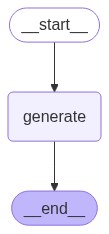

In [10]:
from IPython.display import display, Image

# (옵션) 그래프를 시각화
display(Image(graph.get_graph().draw_mermaid_png()))

In [11]:
from langchain_core.messages import HumanMessage

initial_state = {'messages': [HumanMessage(query)]}
graph.invoke(initial_state)

ai_message: content='저는 Google에서 훈련한 대규모 언어 모델입니다.' additional_kwargs={} response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []} id='run--10d8a8ab-f2c9-441a-9ce2-b05cc3e54458-0' usage_metadata={'input_tokens': 6, 'output_tokens': 252, 'total_tokens': 258, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 239}}


{'messages': [AIMessage(content='저는 Google에서 훈련한 대규모 언어 모델입니다.', additional_kwargs={}, response_metadata={'prompt_feedback': {'block_reason': 0, 'safety_ratings': []}, 'finish_reason': 'STOP', 'model_name': 'gemini-2.5-flash', 'safety_ratings': []}, id='run--10d8a8ab-f2c9-441a-9ce2-b05cc3e54458-0', usage_metadata={'input_tokens': 6, 'output_tokens': 252, 'total_tokens': 258, 'input_token_details': {'cache_read': 0}, 'output_token_details': {'reasoning': 239}})]}